Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import precision_score, recall_score, roc_auc_score, classification_report

Load Dataset

In [ ]:
df = pd.read_csv('/content/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


Dataset Information

In [ ]:
df.shape
df.info()
df['Class'].value_counts()   # 0 = normal, 1 = fraud

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168486 entries, 0 to 168485
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    168486 non-null  float64
 1   V1      168486 non-null  float64
 2   V2      168486 non-null  float64
 3   V3      168486 non-null  float64
 4   V4      168486 non-null  float64
 5   V5      168486 non-null  float64
 6   V6      168486 non-null  float64
 7   V7      168486 non-null  float64
 8   V8      168486 non-null  float64
 9   V9      168486 non-null  float64
 10  V10     168486 non-null  float64
 11  V11     168486 non-null  float64
 12  V12     168485 non-null  float64
 13  V13     168485 non-null  float64
 14  V14     168485 non-null  float64
 15  V15     168485 non-null  float64
 16  V16     168485 non-null  float64
 17  V17     168485 non-null  float64
 18  V18     168485 non-null  float64
 19  V19     168485 non-null  float64
 20  V20     168485 non-null  float64
 21  V21     16

,count
Class,
0.0,168125
1.0,360


Check Missing Values

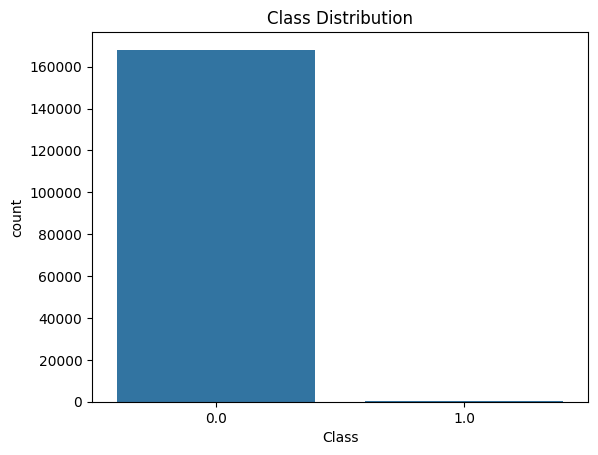

In [ ]:
sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()

Feature & Target Split

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

In [ ]:
print(y.isnull().sum())

1


In [ ]:
import pandas as pd

data = pd.concat([X, y], axis=1)
data = data.dropna(subset=[y.name])
X = data.drop(columns=[y.name])
y = data[y.name]

Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Apply SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_res))

Before SMOTE: [134500    288]
After SMOTE: [134500 134500]


Logistic Regression Model

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_res, y_train_res)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

Random Forest Model

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

Evaluation Metrics

In [ ]:
def evaluate(y_test, y_pred, y_prob, model_name):
    print(f"\n--- {model_name} ---")
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print(classification_report(y_test, y_pred))

In [ ]:
evaluate(y_test, y_pred_lr, y_prob_lr, "Logistic Regression")
evaluate(y_test, y_pred_rf, y_prob_rf, "Random Forest")


--- Logistic Regression ---
Precision: 0.18181818181818182
Recall: 0.8571428571428571
ROC-AUC: 0.9504703115814227
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99      7128
         1.0       0.18      0.86      0.30        21

    accuracy                           0.99      7149
   macro avg       0.59      0.92      0.65      7149
weighted avg       1.00      0.99      0.99      7149


--- Random Forest ---
Precision: 0.9411764705882353
Recall: 0.7619047619047619
ROC-AUC: 0.9736084388862165
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      7128
         1.0       0.94      0.76      0.84        21

    accuracy                           1.00      7149
   macro avg       0.97      0.88      0.92      7149
weighted avg       1.00      1.00      1.00      7149

